# 2025 CITS4012 Individual Assignment
*Make sure you change the file name with your student id.*

# Readme
*If there is something to be noted for the marker, please mention here.*

*If you are planning to implement a program with Object Oriented Programming style, please put those the bottom of this ipynb file*

Please successfully install and import necessary Python packages before running section 1-5 *cells*.

Please attach three csv files (medical_tc_train.csv, medical_tc_test.csv and medical_tc_labels.csv) and pretrained biomedical word embedding (bio_embedding_extrinsic) in the same working directory. If could not find bio_embedding_extrinsic locally, the script will try to fecth from google drive but it need authentication.

For Section 6, it can run independtly with saved medical_classifier_fasttext.pt and medical_classifier_bio.pt, medical_tc_test.csv and medical_tc_labels.csv in the same working directory. In section 6, it will reinstall and reimport necessary libiraries again to ensure it can run independently.

**Pipeline Overview**

1. Dataset Processing

    Cleans text (URLs/HTML, numbers/units, punctuation)

    Tokenizes, lemmatizes, and removes stopwords (keeps key negations)

    Builds label mappings (code2id, id2name, etc.)

2. Word Embedding Construction

    Trains FastText on the training tokens (subword-aware, good for rare medical terms)

    Loads BioWordVec (bio_embedding_extrinsic)

    Builds embedding matrices aligned to the model vocabulary

3. Visualization

    t-SNE plot comparing selected term vectors from the trained FastText vs BioWordVec

4. RNN-based Model Implementation

    BiLSTM (2 layers, bidirectional) with masked mean+max pooling

    Weighted cross-entropy to address class imbalance

    Trains two models (FastText vs BioWordVec embeddings)

5. Performance Evaluation

    Accuracy, weighted F1, and a full classification report on the test set

6. Interactive Inference (Standalone)

    Lightweight loader that reconstructs the model from a saved checkpoint

    Predicts the condition for any chosen test-row abstract

In [ ]:
!pip install gensim
!pip install torch torchvision torchaudio
!pip install scikit-learn
!pip install seaborn
!pip install numpy

# Import necessary libraries
import pandas as pd
import numpy as np
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, classification_report, f1_score
import warnings
warnings.filterwarnings('ignore')

# NLTK imports for text preprocessing
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords as sw
from nltk.tokenize import word_tokenize

# Gensim imports for word embeddings
from gensim.models import Word2Vec, FastText
from gensim.models import KeyedVectors
import gensim.downloader as api
from pathlib import Path
from collections import Counter

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


# 1.Dataset Processing
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

In [ ]:
# Load the datasets
print("Loading datasets...")
train_df = pd.read_csv('medical_tc_train.csv')
test_df = pd.read_csv('medical_tc_test.csv')
labels_df = pd.read_csv('medical_tc_labels.csv')

print(f"Training set shape: {train_df.shape}")
print(f"Test set shape: {test_df.shape}")
print(f"Labels shape: {labels_df.shape}")

# Display first few rows
print("\nTraining data sample:")
print(train_df.head())
print("\nLabels:")
print(labels_df.head())

Loading datasets...
Training set shape: (11550, 2)
Test set shape: (2888, 2)
Labels shape: (5, 2)

Training data sample:
   condition_label                                   medical_abstract
0                5  Tissue changes around loose prostheses. A cani...
1                1  Neuropeptide Y and neuron-specific enolase lev...
2                2  Sexually transmitted diseases of the colon, re...
3                1  Lipolytic factors associated with murine and h...
4                3  Does carotid restenosis predict an increased r...

Labels:
   condition_label                   condition_name
0                1                        neoplasms
1                2        digestive system diseases
2                3          nervous system diseases
3                4          cardiovascular diseases
4                5  general pathological conditions


In [ ]:
# labels_df has columns: condition_label (code), condition_name (text)
labels_sorted = labels_df.sort_values('condition_label').reset_index(drop=True)

code2id   = {int(c): i for i, c in enumerate(labels_sorted['condition_label'])}
id2code   = {i: int(c) for c, i in code2id.items()}
id2name   = {i: n for i, n in enumerate(labels_sorted['condition_name'])}
code2name = dict(zip(labels_sorted['condition_label'], labels_sorted['condition_name']))

# Map datasets using the SAME encoder
train_df['label_id'] = train_df['condition_label'].map(code2id)
test_df['label_id']  = test_df['condition_label'].map(code2id)

# Keep the class count for model head
NUM_CLASSES = len(labels_sorted)

In [ ]:
# Quick token frequency exploration
def preprocess_text_initial(text):
    """A simple version just for finding common words."""
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text) # Simple punctuation removal
    tokens = word_tokenize(text)
    stop_words_initial = set(sw.words('english'))
    tokens = [w for w in tokens if w not in stop_words_initial and len(w) > 1]
    return tokens

# Apply this simple function to create the 'tokens' column
print("Creating a temporary 'tokens' column for analysis...")
train_df['tokens'] = train_df['medical_abstract'].apply(preprocess_text_initial)

# First, get all tokens from the training set
all_train_tokens = [token for sublist in train_df['tokens'] for token in sublist]

# Find the 20 most common words
word_counts = Counter(all_train_tokens)
most_common_words = word_counts.most_common(20)
print("Most common words in corpus:", most_common_words)

Creating a temporary 'tokens' column for analysis...
Most common words in corpus: [('patients', 27649), ('less', 6087), ('disease', 5753), ('group', 5019), ('treatment', 4836), ('study', 4420), ('two', 4100), ('may', 4029), ('one', 3895), ('cases', 3598), ('blood', 3592), ('patient', 3542), ('years', 3529), ('clinical', 3427), ('cells', 3367), ('results', 3329), ('therapy', 2984), ('associated', 2909), ('mean', 2892), ('normal', 2870)]


In [ ]:
# Text preprocessing functions
lemmatizer = WordNetLemmatizer()

#Domain-specific stopword adjustments: keep negation; drop generic medical word
custom_stopwords = {
    'patient', 'group', 'study', 'case', 'treatment', 'year', 'two', 'one',
    'result', 'may', 'effect', 'clinical', 'also', 'found', 'showed'
}
neg_keep = {'no','not','nor','without','none','neither','never'}
stop_words = set(sw.words('english')) - neg_keep
stop_words.update(custom_stopwords)

def preprocess_text(text):
    """Complete text preprocessing pipeline"""
    text = text.lower()
    # strip URLs and HTML
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)

    # Handle numbers more intelligently
    # Keep medically relevant numbers (dosages, measurements, ages)
    text = re.sub(r'\b\d+(?:\.\d+)?(?:mg|ml|mmhg|kg|cm|mm|years?|yr|months?|mo)\b', ' <NUM_UNIT> ', text)
    text = re.sub(r'\b\d+(?:\.\d+)?%\b', ' <PERCENT> ', text)
    text = re.sub(r'\b\d+/\d+\b', ' <RATIO> ', text)  # blood pressure, fractions
    # Remove standalone numbers (likely noise)
    text = re.sub(r'\b\d+(?:\.\d+)?\b', ' ', text)

    # keep hyphens and plus inside tokens
    text = re.sub(r'[^\w\s\-\+<>]', ' ', text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 1]
    return tokens

# Apply preprocessing to training and test data
print("Preprocessing training data...")
train_df['tokens'] = train_df['medical_abstract'].apply(preprocess_text)

print("Preprocessing test data...")
test_df['tokens'] = test_df['medical_abstract'].apply(preprocess_text)

print(f"Sample preprocessed tokens: {train_df['tokens'].iloc[0][:10]}")

print(f"Number of classes: {NUM_CLASSES}")
print("Label mapping created successfully!")

Preprocessing training data...
Preprocessing test data...
Sample preprocessed tokens: ['tissue', 'change', 'around', 'loose', 'prosthesis', 'canine', 'model', 'investigate', 'effect', 'antiinflammatory']
Number of classes: 5
Label mapping created successfully!


# 2.Word Embedding Construction
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

In [ ]:
# Prepare sentences for training word embeddings
train_sentences = train_df['tokens'].tolist()
all_sentences = train_df['tokens'].tolist() + test_df['tokens'].tolist()

print(f"Total sentences for training embeddings: {len(train_sentences)}")
print(f"Sample sentence: {train_sentences[0][:10]}")

Total sentences for training embeddings: 11550
Sample sentence: ['tissue', 'change', 'around', 'loose', 'prosthesis', 'canine', 'model', 'investigate', 'effect', 'antiinflammatory']


In [ ]:
# Train word embeddings
'''FastText is chosen as the primary embedding method for this medical classification task.
1. Handles out-of-vocabulary medical terms
2. Subword information captures morphological patterns (e.g., -itis, -ology)
3. Better performance on rare medical terminology
4. Can generate embeddings for unseen compound medical words
'''

# Train FastText model
print("Training FastText model...")
fasttext_model = FastText(sentences=train_sentences,
                         vector_size=200,
                         window=5,
                         min_count=3,
                         workers=4,
                         sg=1, # Skip-gram (better for rare words)
                         epochs=15)

print("FastText model trained successfully!")

# Test FastText with medical terms
print("Testing FastText on Medical Terms")
medical_test_words = ['diabetes', 'hypertension', 'pneumonia', 'cardiomyopathy', 'bronchitis']

for word in medical_test_words:
    if word in fasttext_model.wv:
        print(f"\nSimilar words to '{word}' (FastText):")
        similar = fasttext_model.wv.most_similar(word, topn=3)
        for sim_word, score in similar:
            print(f"  {sim_word}: {score:.3f}")
    else:
        print(f"'{word}' not in vocabulary, but FastText can still generate embeddings!")

Training FastText model...
FastText model trained successfully!
Testing FastText on Medical Terms

Similar words to 'diabetes' (FastText):
  mellitus: 0.876
  diabetic: 0.726
  prediabetic: 0.676

Similar words to 'hypertension' (FastText):
  hypertensive: 0.784
  nonhypertensive: 0.756
  prehypertensive: 0.755

Similar words to 'pneumonia' (FastText):
  pneumoniae: 0.922
  pneumonitis: 0.848
  pneumocystis: 0.790

Similar words to 'cardiomyopathy' (FastText):
  cardiomyopathic: 0.900
  cardiomyoplasty: 0.768
  myopathy: 0.751

Similar words to 'bronchitis' (FastText):
  bronchiolitis: 0.908
  tracheobronchitis: 0.851
  bronchiole: 0.834


In [ ]:
#1) Load BioWordVec in the working directory
local_bio_path = 'bio_embedding_extrinsic'
bio_wv = None
if Path(local_bio_path).exists():
  try:
    bio_wv = KeyedVectors.load_word2vec_format(local_bio_path, binary=True)
    print(f"BioWordVec loaded from local: {local_bio_path} (vocab size: {len(bio_wv)})")
  except Exception as e:
    print(f"Local BioWordVec load failed: {e}")

#2) Google Drive fallback
if bio_wv is None:
  try:
    from google.colab import drive
    drive.mount('/content/drive')
    drive_bio_path = '/content/drive/MyDrive/NLP/bio_embedding_extrinsic'
    bio_wv = KeyedVectors.load_word2vec_format(drive_bio_path, binary=True)
    print(f"BioWordVec loaded from Drive: {drive_bio_path} (vocab size: {len(bio_wv)})")
  except Exception as e:
    print(f"Drive BioWordVec load failed: {e}")


Mounted at /content/drive
BioWordVec loaded from Drive: /content/drive/MyDrive/NLP/bio_embedding_extrinsic (vocab size: 2324849)


In [ ]:

# Build vocabulary from training data
def build_vocabulary(sentences, min_count=4):
    """Build vocabulary with word frequencies"""
    word_freq = {}
    for sentence in sentences:
        for word in sentence:
            word_freq[word] = word_freq.get(word, 0) + 1

    # Filter by minimum count and add special tokens
    vocab = {'<pad>': 0, '<unk>': 1}
    idx = 2
    for word, freq in word_freq.items():
        if freq >= min_count:
            vocab[word] = idx
            idx += 1

    return vocab

# Build vocabulary
vocab = build_vocabulary(train_sentences, min_count=3)
vocab_size = len(vocab)
print(f"Vocabulary size: {vocab_size}")

# Create reverse vocabulary mapping
idx_to_word = {idx: word for word, idx in vocab.items()}

#Create embedding matrices aligned with vocab
def create_embedding_matrix(vocab, embedding_model, embedding_dim=200, use_fasttext_oov=False):
    W = np.random.normal(0, 0.1, (len(vocab), embedding_dim)).astype(np.float32)
    for word, idx in vocab.items():
        if word in ('<pad>', '<unk>'):
            continue
        try:
            if hasattr(embedding_model, 'wv'):  # gensim FastText model
                if use_fasttext_oov and hasattr(embedding_model.wv, 'get_vector'):
                    W[idx] = embedding_model.wv.get_vector(word)   # works for OOV (FastText)
                elif word in embedding_model.wv:
                    W[idx] = embedding_model.wv[word]
            else:                                # KeyedVectors (BioWordVec)
                if word in embedding_model:
                    W[idx] = embedding_model[word]
        except Exception:
            pass
    return W

# Create embedding matrices
print("Creating embedding matrices...")
fasttext_dim = fasttext_model.wv.vector_size
bio_dim = getattr(bio_wv, 'vector_size', getattr(getattr(bio_wv, 'wv', None), 'vector_size', 200))
fasttext_embedding_matrix = create_embedding_matrix(vocab, fasttext_model, fasttext_dim, use_fasttext_oov=True)
bio_embedding_matrix = create_embedding_matrix(vocab, bio_wv, bio_dim)

print("Embedding matrices created successfully!")
print(f"FastText embedding matrix shape: {fasttext_embedding_matrix.shape}")
print(f"Bio embedding matrix shape: {bio_embedding_matrix.shape}")

Vocabulary size: 20472
Creating embedding matrices...
Embedding matrices created successfully!
FastText embedding matrix shape: (20472, 200)
Bio embedding matrix shape: (20472, 200)


# 3.Visualization
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

Creating t-SNE visualization for medical terms...
Found embeddings for 20 term-model combinations


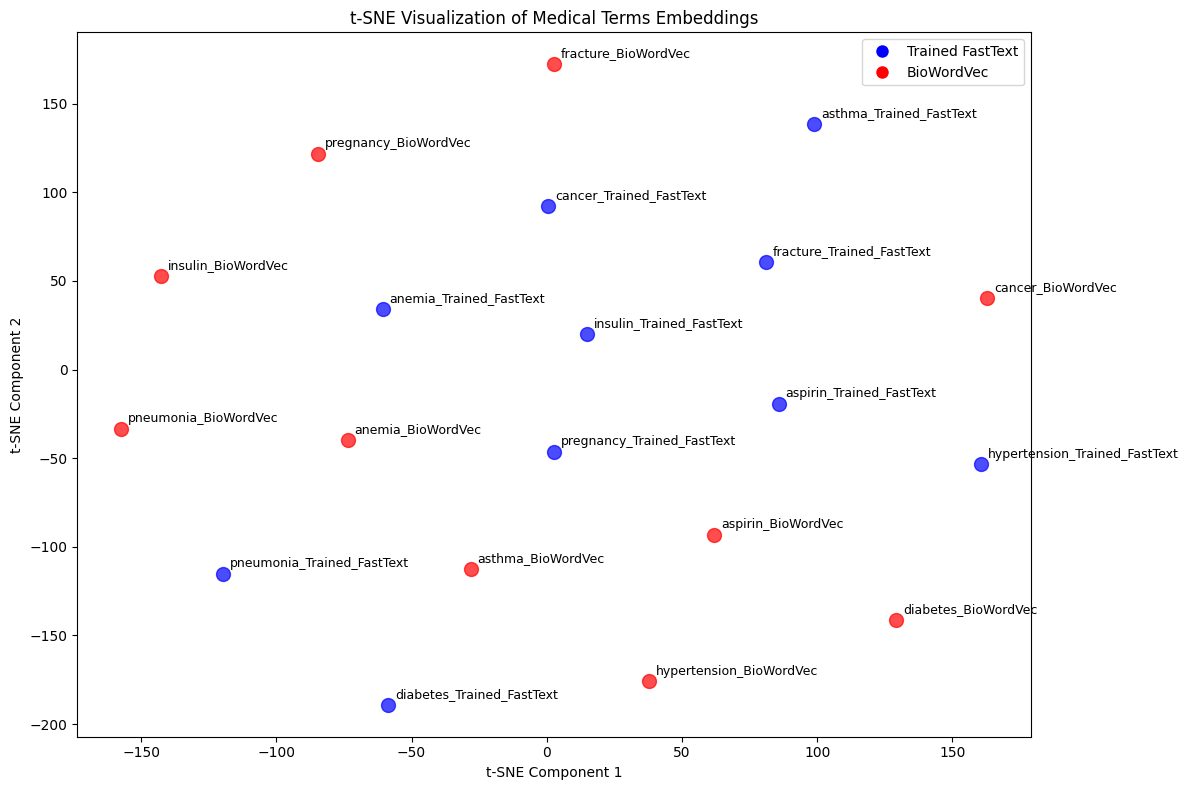

In [ ]:
# Select 10 medical terms for visualization
medical_terms = ['diabetes', 'insulin', 'hypertension', 'asthma', 'pneumonia',
                'anemia', 'aspirin', 'pregnancy', 'fracture', 'cancer']

print("Creating t-SNE visualization for medical terms...")

def get_embeddings_for_terms(terms, model1, model2, model1_name="Trained", model2_name="BioWordVec"):
    """Extract embeddings for given terms from two models"""
    embeddings = []
    labels = []
    colors = []

    for term in terms:
        # Try to get embedding from first model (trained)
        try:
            if hasattr(model1, 'wv'):
                if term in model1.wv:
                    embeddings.append(model1.wv[term])
                    labels.append(f"{term}_{model1_name}")
                    colors.append('blue')
            else:
                if term in model1:
                    embeddings.append(model1[term])
                    labels.append(f"{term}_{model1_name}")
                    colors.append('blue')
        except:
            pass

        # Try to get embedding from second model (bio)
        try:
            if hasattr(model2, 'wv'):
                if term in model2.wv:
                    embeddings.append(model2.wv[term])
                    labels.append(f"{term}_{model2_name}")
                    colors.append('red')
            else:
                if term in model2:
                    embeddings.append(model2[term])
                    labels.append(f"{term}_{model2_name}")
                    colors.append('red')
        except:
            pass

    return np.array(embeddings), labels, colors

# Get embeddings for visualization
embeddings_array, embedding_labels, embedding_colors = get_embeddings_for_terms(
    medical_terms, fasttext_model, bio_wv, "Trained_FastText", "BioWordVec"
)

if len(embeddings_array) > 0:
    print(f"Found embeddings for {len(embeddings_array)} term-model combinations")

    # Apply t-SNE (robust perplexity)
    n = len(embeddings_array)
    if n < 3:
        print("Not enough points for t-SNE (need >= 3). Skipping plot.")
    else:
        perp = max(2, min(30, n - 1))
        tsne = TSNE(n_components=2, perplexity=perp, random_state=42, max_iter=1000)
        tsne_results = tsne.fit_transform(embeddings_array)
        # Create visualization
        plt.figure(figsize=(12, 8))
        # Plot points with different colors for different models
        for i, (label, color) in enumerate(zip(embedding_labels, embedding_colors)):
            plt.scatter(tsne_results[i, 0], tsne_results[i, 1],
                       c=color, s=100, alpha=0.7)
            plt.annotate(label, (tsne_results[i, 0], tsne_results[i, 1]),
                        xytext=(5, 5), textcoords='offset points', fontsize=9)
        plt.title('t-SNE Visualization of Medical Terms Embeddings')
        plt.xlabel('t-SNE Component 1')
        plt.ylabel('t-SNE Component 2')
        # Create legend
        from matplotlib.lines import Line2D
        legend_elements = [Line2D([0], [0], marker='o', color='w',
                                 markerfacecolor='blue', markersize=10, label='Trained FastText'),
                          Line2D([0], [0], marker='o', color='w',
                                 markerfacecolor='red', markersize=10, label='BioWordVec')]
        plt.legend(handles=legend_elements)
        plt.tight_layout()
        plt.show()

Visualization Interpretation

The chart is a t-SNE projection of word vectors from two sources: blue = FastText, red = BioWordVec.

t-SNE only preserves very local neighborhoods and the axes/overall distances don't have direct meaning.

The main takeaway is that the two models arrange the same medical terms into different neighborhoods.

This plot alone does not show that one model is “tighter” or “better.” For example, obvious pairs like insulin and diabetes are not consistently close in either color here.

So use this figure only as a qualitative illustration.

# 4.RNN-based Model Implementation
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

In [ ]:
# Sequence processing functions for model preparation
def tokenize_and_pad(texts, vocab, max_length=300):
    """Convert texts to padded sequences"""
    sequences = []
    for text in texts:
        seq = [vocab.get(word, vocab['<unk>']) for word in text]
        # Pad or truncate
        if len(seq) < max_length:
            seq.extend([vocab['<pad>']] * (max_length - len(seq)))
        else:
            seq = seq[:max_length]
        sequences.append(seq)
    return np.array(sequences)

# Prepare data for model training
train_lens = train_df['tokens'].str.len().to_list()
MAX_LENGTH = min(500, int(np.percentile(train_lens, 95)))

print("Preparing sequences for model training...")
X_train = tokenize_and_pad(train_df['tokens'], vocab, MAX_LENGTH)
y_train = train_df['label_id'].values

X_test = tokenize_and_pad(test_df['tokens'], vocab, MAX_LENGTH)
y_test = test_df['label_id'].values

print(f"Training sequences shape: {X_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test sequences shape: {X_test.shape}")
print(f"Test labels shape: {y_test.shape}")

# Convert to tensors
X_train_tensor = torch.LongTensor(X_train)
y_train_tensor = torch.LongTensor(y_train)
X_test_tensor = torch.LongTensor(X_test)
y_test_tensor = torch.LongTensor(y_test)

print("Data preparation completed!")

Preparing sequences for model training...
Training sequences shape: (11550, 176)
Training labels shape: (11550,)
Test sequences shape: (2888, 176)
Test labels shape: (2888,)
Data preparation completed!


In [ ]:
# Define the RNN model architecture (BiLSTM classifier with masked mean+max pooling)
class MedicalTextClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim,
                 embedding_matrix=None, dropout_rate=0.5,
                 pad_idx=None):
        super(MedicalTextClassifier, self).__init__()
        self.pad_idx = 0 if pad_idx is None else int(pad_idx)

        # Embedding layer (use padding_idx if available)
        if pad_idx is not None:
            self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        else:
            self.embedding = nn.Embedding(vocab_size, embedding_dim)

        if embedding_matrix is not None:
            self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))

        # Bidirectional, 2-layer LSTM so internal dropout is actually used
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=2,
                            batch_first=True, bidirectional=True, dropout=0.5)

        # Classifier dropout (before final Linear)
        self.dropout = nn.Dropout(dropout_rate)
        self.embed_dropout = nn.Dropout(0.50)

        # Final classification layer
        self.classifier = nn.Linear(hidden_dim * 4, NUM_CLASSES)

    def forward(self, x):
        emb = self.embed_dropout(self.embedding(x))                  # [B, T, E]
        lstm_out, _ = self.lstm(emb)             # [B, T, 2H]

        # masks for padding
        mask = (x != self.pad_idx)               # [B, T] booleans
        mask_u = mask.unsqueeze(-1)              # [B, T, 1]

        # masked max: pads -> -inf so they never win
        lstm_max = lstm_out.masked_fill(~mask_u, float('-inf')).amax(dim=1)        # [B, 2H]

        # masked mean: pads -> 0, divide by valid length
        valid_counts = mask.sum(1).clamp_min(1).unsqueeze(-1)                      # [B, 1]
        lstm_mean = lstm_out.masked_fill(~mask_u, 0.0).sum(dim=1) / valid_counts   # [B, 2H]

        pooled = torch.cat([lstm_max, lstm_mean], dim=1)                            # [B, 4H]
        logits = self.classifier(self.dropout(pooled))
        return logits

# Model parameters
EMBEDDING_DIM_FASTTEXT = fasttext_dim
EMBEDDING_DIM_BIO = bio_dim
HIDDEN_DIM = 128
OUTPUT_DIM = NUM_CLASSES
BATCH_SIZE = 32
LEARNING_RATE = 0.0005
EPOCHS_fasttext = 5
EPOCHS_bio = 18

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Training function
def train_model(model, train_loader, criterion, optimizer, device, num_epochs):
    """Train the model and return training history"""
    model.train()
    train_losses = []
    train_accuracies = []

    for epoch in range(num_epochs):
        epoch_loss = 0
        correct_predictions = 0
        total_predictions = 0

        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)

            # Zero gradients
            optimizer.zero_grad()

            # Forward pass
            output = model(data)
            loss = criterion(output, target)

            # Backward pass
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            # Statistics
            epoch_loss += loss.item()
            _, predicted = torch.max(output.data, 1)
            total_predictions += target.size(0)
            correct_predictions += (predicted == target).sum().item()

        # Calculate epoch metrics
        avg_loss = epoch_loss / len(train_loader)
        accuracy = correct_predictions / total_predictions

        train_losses.append(avg_loss)
        train_accuracies.append(accuracy)

        if (epoch + 1) % 2 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4f}')

    return train_losses, train_accuracies

# Create data loaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Using device: cuda


In [ ]:
# Class-imbalance handling via frequency-based weights
cnt = Counter(y_train)
freq = np.array([cnt[i] for i in range(NUM_CLASSES)], dtype=np.float32)
inv = (freq.sum() / freq)
alpha = 0.5
w = (inv ** alpha)
w = torch.tensor(w, dtype=torch.float, device=device)

criterion = nn.CrossEntropyLoss(weight=w, label_smoothing=0.02)

In [ ]:
# Model A: Using trained FastText embeddings
print("Training Model A: FastText Embeddings")
model_fasttext = MedicalTextClassifier(
    vocab_size, EMBEDDING_DIM_FASTTEXT, HIDDEN_DIM, OUTPUT_DIM,
    fasttext_embedding_matrix, dropout_rate=0.5, pad_idx=vocab['<pad>']
).to(device)

optimizer_fasttext = optim.AdamW(model_fasttext.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

# Train Model A (FastText)
train_losses_ft, train_acc_ft = train_model(model_fasttext, train_loader, criterion,
                                           optimizer_fasttext, device, EPOCHS_fasttext)

# Save Model A with complete metadata
torch.save({
    'model_state_dict': model_fasttext.state_dict(),
    'vocab': vocab,
    'max_length': MAX_LENGTH,
    'embedding_dim': EMBEDDING_DIM_FASTTEXT,
    'hidden_dim': HIDDEN_DIM,
    'output_dim': OUTPUT_DIM,
    'vocab_size': vocab_size,
    'num_classes': NUM_CLASSES,
    'pad_idx': vocab['<pad>'],
    'code2name': code2name,
    'id2name': id2name,
    'model_type': 'fasttext'
}, 'medical_classifier_fasttext.pt')

print("Model A (FastText) saved with metadata!")


Training Model A: FastText Embeddings
Epoch [2/5], Loss: 0.9469, Accuracy: 0.6209
Epoch [4/5], Loss: 0.8303, Accuracy: 0.6689
Model A (FastText) saved with metadata!


In [ ]:
# Model B: Using BioWordVec embeddings
print("Training Model B: BioWordVec Embeddings")
model_bio = MedicalTextClassifier(
    vocab_size, EMBEDDING_DIM_BIO, HIDDEN_DIM, OUTPUT_DIM,
    bio_embedding_matrix, dropout_rate=0.5, pad_idx=vocab['<pad>']
).to(device)

optimizer_bio =  optim.AdamW([{'params': model_bio.embedding.parameters(), 'lr': 1e-5},  # Smaller LR for embeddings
    {'params': model_bio.lstm.parameters(), 'lr': 1e-3},       # Larger LR for LSTM
    {'params': model_bio.classifier.parameters(), 'lr': 1e-3}  # Larger LR for classifier
], weight_decay=1e-4)

# Train Model B
train_losses_bio, train_acc_bio = train_model(model_bio, train_loader, criterion,
                                             optimizer_bio, device, EPOCHS_bio)

# Save Model B with complete metadata
torch.save({
    'model_state_dict': model_bio.state_dict(),
    'vocab': vocab,
    'max_length': MAX_LENGTH,
    'embedding_dim': EMBEDDING_DIM_BIO,
    'hidden_dim': HIDDEN_DIM,
    'output_dim': OUTPUT_DIM,
    'vocab_size': vocab_size,
    'num_classes': NUM_CLASSES,
    'pad_idx': vocab['<pad>'],
    'code2name': code2name,
    'id2name': id2name,
    'model_type': 'biowordvec'
}, 'medical_classifier_bio.pt')

print("Model B (BioWordVec) saved with metadata!")

Training Model B: BioWordVec Embeddings
Epoch [2/18], Loss: 0.9338, Accuracy: 0.6271
Epoch [4/18], Loss: 0.8760, Accuracy: 0.6425
Epoch [6/18], Loss: 0.8466, Accuracy: 0.6515
Epoch [8/18], Loss: 0.8205, Accuracy: 0.6567
Epoch [10/18], Loss: 0.8063, Accuracy: 0.6646
Epoch [12/18], Loss: 0.7822, Accuracy: 0.6758
Epoch [14/18], Loss: 0.7678, Accuracy: 0.6805
Epoch [16/18], Loss: 0.7508, Accuracy: 0.6823
Epoch [18/18], Loss: 0.7392, Accuracy: 0.6821
Model B (BioWordVec) saved with metadata!


# 5.Performance Evaluation
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

In [ ]:
def evaluate_model(model, data_loader, device):
  model.eval()
  preds, tgts = [], []
  with torch.no_grad():
    for x, y in data_loader:
      x, y = x.to(device), y.to(device)
      logits = model(x)
      preds.extend(logits.argmax(dim=1).cpu().numpy())
      tgts.extend(y.cpu().numpy())
  return np.array(preds), np.array(tgts)

In [ ]:
# Build label list and names in the numeric order
labels = list(range(len(labels_sorted)))
target_names = [id2name[i] for i in labels]

def print_eval(true_ids, pred_ids, title):
    print(title)
    print(f"Accuracy: {accuracy_score(true_ids, pred_ids):.4f}")
    print(f"F1-Score (weighted): {f1_score(true_ids, pred_ids, average='weighted'):.4f}")
    print("Classification Report:")
    print(classification_report(true_ids, pred_ids, labels=labels, target_names=target_names, digits=3))

# FastText
pred_ft, true_ft = evaluate_model(model_fasttext, test_loader, device)
print_eval(true_ft, pred_ft, "1. FastText Model Evaluation:")

# BioWordVec
pred_bio, true_bio = evaluate_model(model_bio, test_loader, device)
print_eval(true_bio, pred_bio, "2. BioWordVec Model Evaluation:")

1. FastText Model Evaluation:
Accuracy: 0.6229
F1-Score (weighted): 0.6079
Classification Report:
                                 precision    recall  f1-score   support

                      neoplasms      0.701     0.803     0.748       633
      digestive system diseases      0.513     0.652     0.574       299
        nervous system diseases      0.528     0.764     0.624       385
        cardiovascular diseases      0.684     0.761     0.720       610
general pathological conditions      0.617     0.352     0.448       961

                       accuracy                          0.623      2888
                      macro avg      0.609     0.666     0.623      2888
                   weighted avg      0.627     0.623     0.608      2888

2. BioWordVec Model Evaluation:
Accuracy: 0.6517
F1-Score (weighted): 0.6350
Classification Report:
                                 precision    recall  f1-score   support

                      neoplasms      0.698     0.815     0.752      

**Evaluation result analysis:**
1. Neoplasms & Cardiovascular Diseases (Excellent Performance): These are the strongest classes because they use a highly specific vocabulary. This creates a unambiguous signal that the model easily learns.
2. Nervous System & Digestive System Diseases (Good Performance): These classes perform well because they also have a strong core vocabulary. However, they are slightly harder because their topics are more diverse and can sometimes overlap with other categories, making the signal a little less distinct.
3. General Pathological Conditions (Poor Performance): This is the weakest class because it's a miscellaneous category. The abstracts within it are about many different, unrelated topics. This means there is no consistent vocabulary for the model to learn, leading to confusion and low recall.

# 6.Interactive Inference Colab Form
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

In [ ]:
# Install and import dependencies
!pip install torch scikit-learn nltk pandas numpy

import pandas as pd
import numpy as np
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords as sw
from nltk.tokenize import word_tokenize

# Download NLTK data
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# Recreate preprocessing function
def preprocess_text_standalone(text):
    """Standalone preprocessing - matches original exactly"""
    lemmatizer = WordNetLemmatizer()

    custom_stopwords = {
        'patient', 'group', 'study', 'case', 'treatment', 'year', 'two', 'one',
        'result', 'may', 'effect', 'clinical', 'also', 'found', 'showed'
    }
    neg_keep = {'no','not','nor','without','none','neither','never'}
    stop_words = set(sw.words('english')) - neg_keep
    stop_words.update(custom_stopwords)

    text = text.lower()
    # strip URLs and HTML
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)

    # Handle numbers more intelligently
    # Keep medically relevant numbers (dosages, measurements, ages)
    text = re.sub(r'\b\d+(?:\.\d+)?(?:mg|ml|mmhg|kg|cm|mm|years?|yr|months?|mo)\b', ' <NUM_UNIT> ', text)
    text = re.sub(r'\b\d+(?:\.\d+)?%\b', ' <PERCENT> ', text)
    text = re.sub(r'\b\d+/\d+\b', ' <RATIO> ', text)  # blood pressure, fractions
    # Remove standalone numbers (likely noise)
    text = re.sub(r'\b\d+(?:\.\d+)?\b', ' ', text)

    # keep hyphens and plus inside tokens
    text = re.sub(r'[^\w\s\-\+<>]', ' ', text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 1]
    return tokens

# Recreate model architecture
class MedicalTextClassifierStandalone(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, pad_idx=0):
        super(MedicalTextClassifierStandalone, self).__init__()
        self.pad_idx = pad_idx

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=2,
                            batch_first=True, bidirectional=True, dropout=0.5)
        self.dropout = nn.Dropout(0.5)
        self.embed_dropout = nn.Dropout(0.50)
        self.classifier = nn.Linear(hidden_dim * 4, output_dim)

    def forward(self, x):
        emb = self.embed_dropout(self.embedding(x))
        lstm_out, _ = self.lstm(emb)
        mask = (x != self.pad_idx)
        mask_u = mask.unsqueeze(-1)
        lstm_max = lstm_out.masked_fill(~mask_u, float('-inf')).amax(dim=1)
        valid_counts = mask.sum(1).clamp_min(1).unsqueeze(-1)
        lstm_mean = lstm_out.masked_fill(~mask_u, 0.0).sum(dim=1) / valid_counts
        pooled = torch.cat([lstm_max, lstm_mean], dim=1)
        logits = self.classifier(self.dropout(pooled))
        return logits

def load_model_and_predict_standalone(model_path, text):
    """Load model from checkpoint and predict"""
    print(f"Loading model from: {model_path}")

    # Load checkpoint
    checkpoint = torch.load(model_path, map_location='cpu')

    # Extract all needed info from checkpoint
    vocab = checkpoint['vocab']
    max_length = checkpoint['max_length']
    id2name = checkpoint['id2name']

    # Recreate model
    model = MedicalTextClassifierStandalone(
        vocab_size=checkpoint['vocab_size'],
        embedding_dim=checkpoint['embedding_dim'],
        hidden_dim=checkpoint['hidden_dim'],
        output_dim=checkpoint['output_dim'],
        pad_idx=checkpoint['pad_idx']
    )

    # Load trained weights
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    # Preprocess text
    tokens = preprocess_text_standalone(text)
    seq = [vocab.get(tok, vocab['<unk>']) for tok in tokens]

    # Pad sequence
    if len(seq) < max_length:
        seq = seq + [vocab['<pad>']] * (max_length - len(seq))
    else:
        seq = seq[:max_length]

    # Make prediction
    x = torch.tensor([seq], dtype=torch.long)
    with torch.no_grad():
        logits = model(x)
        probs = F.softmax(logits, dim=1).squeeze(0).numpy()

    pred_id = int(probs.argmax())
    confidence = float(probs[pred_id])

    return pred_id, confidence, probs, id2name

#@title Medical Abstract Classification — Standalone Inference
#@markdown Choose embedding and test row number. Loads models from saved files.
embedding_choice = "trained_fasttext"  #@param ["trained_fasttext", "biowordvec"]
test_row_number = 23                    #@param {type:"integer"}

# Load test data and labels
print("Loading test data...")
test_df = pd.read_csv('medical_tc_test.csv').reset_index(drop=True)
labels_df = pd.read_csv('medical_tc_labels.csv')

# Recreate label mappings
labels_sorted = labels_df.sort_values('condition_label').reset_index(drop=True)
code2name = dict(zip(labels_sorted['condition_label'], labels_sorted['condition_name']))

print(f"Loaded {len(test_df)} test samples")
print(f"Found {len(labels_sorted)} medical conditions")

# Select model file
if embedding_choice == "trained_fasttext":
    model_path = 'medical_classifier_fasttext.pt'
    model_name = "FastText"
else:
    model_path = 'medical_classifier_bio.pt'
    model_name = "BioWordVec"

print(f"\nUsing {model_name} model")
print("-" * 70)

# Get test sample
i = int(np.clip(test_row_number, 1, len(test_df))) - 1
row = test_df.iloc[i]
abstract = row['medical_abstract']
gold_code = int(row['condition_label'])
gold_name = code2name[gold_code]

# Make prediction using standalone function
try:
    pred_id, confidence, prob_vec, id2name = load_model_and_predict_standalone(model_path, abstract)
    pred_name = id2name[pred_id]

    # Display results
    print(f"Row: {test_row_number}")
    print(f"Abstract: {abstract}")
    print(f"Ground truth: {gold_name} ({gold_code})")
    print(f"Prediction: {pred_name} (p={confidence:.3f})")

except Exception as e:
    print(f"Error: {e}")
    print("\nMake sure you have:")
    print("1. Have medical_classifier_bio.pt and medical_classifier_fasttext.pt files in the same directory")
    print("2. Have medical_tc_test.csv and medical_tc_labels.csv in the same directory")

Loading test data...
Loaded 2888 test samples
Found 5 medical conditions

Using FastText model
----------------------------------------------------------------------
Loading model from: medical_classifier_fasttext.pt
Row: 23
Abstract: Appraisal of gut lavage in the study of intestinal humoral immunity. Direct investigation of intestinal humoral immunity requires collection of intestinal secretions or mucosal biopsy specimens, or both. A non-invasive technique of gut lavage, with a polyethyleneglycol electrolyte lavage solution as a means of collecting intestinal secretions for immunoglobulin and antibody studies, was evaluated. Fifty patients were studied--25 immunologically normal patients or volunteers, 15 patients with untreated coeliac disease, and 10 patients with active Crohn's disease. Protease inhibitors were added promptly to samples to prevent proteolysis of immunoglobulin content. Treated lavage samples were assayed by enzyme linked immunosorbent assay for immunoglobulin and